In [1]:
# подключаем необходимые пакеты:
 import Pkg
 Pkg.add("DifferentialEquations")
 using DifferentialEquations

    Updating registry at `C:\Users\Home\.julia\registries\General.toml`
   Resolving package versions...
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Manifest.toml`
Precompiling project...
  19614.8 ms  ✓ OrdinaryDiffEqNonlinearSolve
  40269.9 ms  ✓ BoundaryValueDiffEq
  31700.0 ms  ✓ OrdinaryDiffEqStabilizedIRK
  34458.9 ms  ✓ OrdinaryDiffEqPDIRK
  38851.5 ms  ✓ OrdinaryDiffEqSDIRK
  47324.0 ms  ✓ StochasticDiffEq
  20336.1 ms  ✓ OrdinaryDiffEqIMEXMultistep
  40301.3 ms  ✓ OrdinaryDiffEqBDF
  66814.6 ms  ✓ OrdinaryDiffEqFIRK
  64221.4 ms  ✓ OrdinaryDiffEqDefault
  11587.9 ms  ✓ OrdinaryDiffEq
  12028.3 ms  ✓ DelayDiffEq
  24563.7 ms  ✓ DifferentialEquations
  13 dependencies successfully precompiled in 326 seconds. 494 already precompiled.


In [18]:
ENV["PYTHON"] = "C:\\Users\\Home\\AppData\\Local\\Programs\\Python\\Python310\\python.exe"; 
using Pkg; 
Pkg.add("Plots")
Pkg.build("PyCall")
Pkg.add("PyPlot")
Pkg.add("Plotly")
Pkg.add("UnicodePlots")
# подключаем для использования Plots:
using Plots

   Resolving package versions...
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Manifest.toml`
    Building Conda ─→ `C:\Users\Home\.julia\scratchspaces\44cfe95a-1eb2-52ea-b672-e2afdf69b78f\8f06b0cfa4c514c7b9546756dbae91fcfbc92dc9\build.log`
    Building PyCall → `C:\Users\Home\.julia\scratchspaces\44cfe95a-1eb2-52ea-b672-e2afdf69b78f\9816a3826b0ebf49ab4926e2b18842ad8b5c8f04\build.log`
   Resolving package versions...
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Manifest.toml`
   Resolving package versions...
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Project.toml`
  No Changes to `C:\Users\Home\.julia\environments\v1.11\Manifest.toml`


In [9]:
# задаём описание модели с начальными условиями:
a = 0.98
f(u,p,t) = a*u
u0 = 1.0

# задаём интервал времени:
tspan = (0.0,1.0)

prob = ODEProblem(f,u0,tspan)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 5-element Vector{Float64}:
 0.0
 0.10042494449239292
 0.3521860297865888
 0.6934436122197829
 1.0
u: 5-element Vector{Float64}:
 1.0
 1.1034222047865465
 1.4121908713484919
 1.9730384457359198
 2.6644561424814266

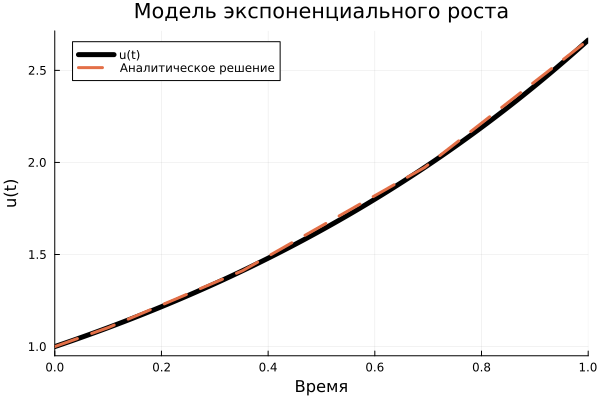

In [5]:
# строим графики:
plot(sol, linewidth=3, title="Модель экспоненциального роста", xaxis="Время", yaxis="u(t)", label="u(t)", color="black")
plot!(sol.t, t->1.0*exp(a*t), lw=3, ls=:dash, label="Аналитическое решение")

In [11]:
sol = solve(prob,abstol=1e-8,reltol=1e-8)

retcode: Success
Interpolation: 3rd order Hermite
t: 9-element Vector{Float64}:
 0.0
 0.04127492324135852
 0.14679917457239627
 0.2863153763968216
 0.43819404263820116
 0.6118923088547421
 0.7985657481708535
 0.9993514410032294
 1.0
u: 9-element Vector{Float64}:
 1.0
 1.0412786454705882
 1.1547261208857074
 1.3239094565289573
 1.5363817850042807
 1.8214892991042442
 2.187139297776232
 2.6627632840763393
 2.6644562419335163

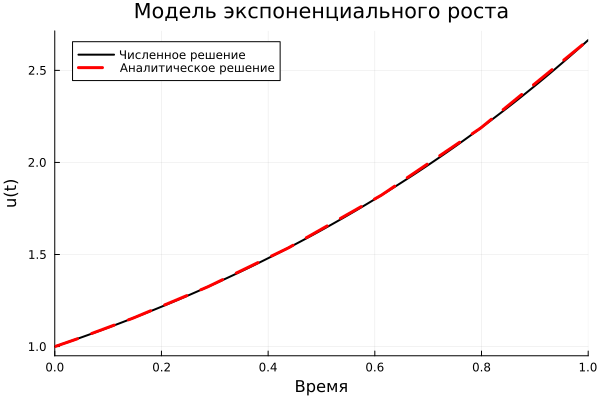

In [12]:
# строим график:
plot(sol, lw=2, color="black", title="Модель экспоненциального роста", xaxis="Время", yaxis="u(t)", label="Численное решение")
plot!(sol.t, t->1.0*exp(a*t),lw=3,ls=:dash,color="red",label="Аналитическое решение")

In [13]:
# задаём описание модели:
function lorenz!(du,u,p,t)
    σ,ρ,β = p
    du[1] = σ*(u[2]-u[1])
    du[2] = u[1]*(ρ-u[3])- u[2]
    du[3] = u[1]*u[2]- β*u[3]
end

lorenz! (generic function with 1 method)

In [14]:
# задаём начальное условие:
u0 = [1.0, 0.0, 0.0]

# задаём знанчения параметров:
p = (10, 28, 8/3)

# задаём интервал времени:
tspan = (0.0, 100.0)

# решение:
prob = ODEProblem(lorenz!, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 1292-element Vector{Float64}:
   0.0
   3.5678604836301404e-5
   0.0003924646531993154
   0.003262408731175873
   0.009058076622686189
   0.01695647090176743
   0.027689960116420883
   0.041856352219618344
   0.060240411865493296
   0.08368541210909924
   0.11336499336103911
   0.14862181393426632
   0.1870397836913972
   ⋮
  99.25245983911758
  99.3123010170333
  99.37100059024901
  99.43545175575305
  99.50217600300971
  99.56297541572351
  99.62622492183432
  99.69561088424294
  99.77387244562912
  99.86354266863755
  99.93826978918452
 100.0
u: 1292-element Vector{Vector{Float64}}:
 [1.0, 0.0, 0.0]
 [0.9996434557625105, 0.0009988049817849058, 1.781434788799189e-8]
 [0.9961045497425811, 0.010965399721242457, 2.1469553658389193e-6]
 [0.9693591548287857, 0.0897706331002921, 0.00014380191884671585]
 [0.9242043547708632, 0.24228915014052968, 0.0010461625485930237]
 [0.8800455783133068, 0.43873649717821195, 0.003424260078582332]
 [0.84

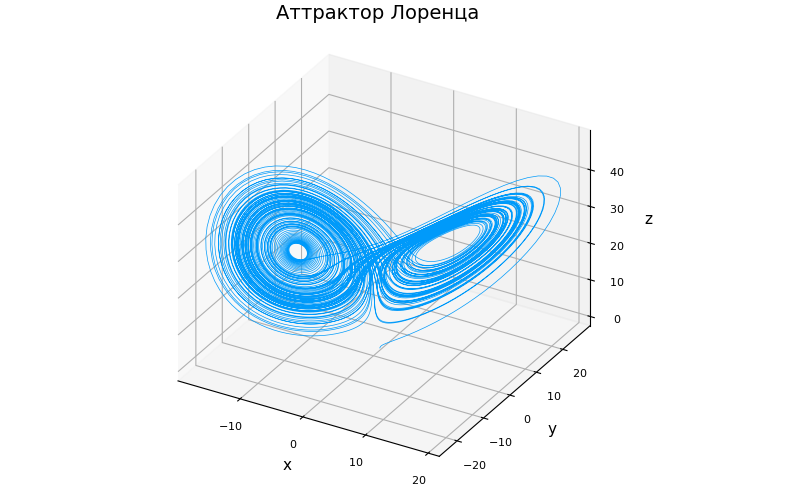

In [25]:
pyplot()
plot(sol, vars=(1,2,3), lw=0.5, title="Аттрактор Лоренца", xaxis="x", yaxis="y", zaxis="z", legend=false, size=(800, 500))

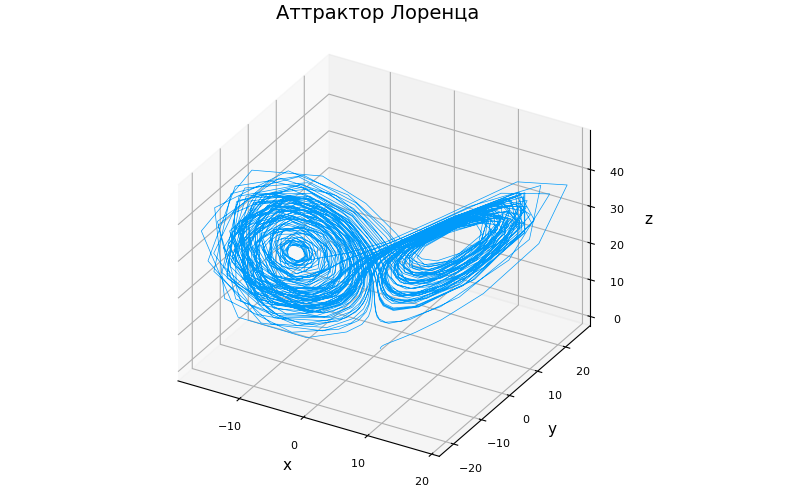

In [27]:
plot(sol, vars=(1,2,3), denseplot=false, lw=0.5, title="Аттрактор Лоренца", xaxis="x", yaxis="y", zaxis="z", 
    legend=false,  size=(800, 500))

In [28]:
import Pkg
Pkg.add("ParameterizedFunctions")
using ParameterizedFunctions

   Resolving package versions...
   Installed FindFirstFunctions ──────── v1.4.2
   Installed GR_jll ──────────────────── v0.73.19+1
   Installed PDMats ──────────────────── v0.11.36
   Installed OffsetArrays ────────────── v1.17.0
   Installed MutableArithmetics ──────── v1.6.7
   Installed DomainSets ──────────────── v0.7.16
   Installed Measures ────────────────── v0.3.3
   Installed PlotUtils ───────────────── v1.4.4
   Installed JuliaFormatter ──────────── v2.2.0
   Installed Bijections ──────────────── v0.2.2
   Installed FFMPEG ──────────────────── v0.4.5
   Installed FastPower ───────────────── v1.2.0
   Installed Tricks ──────────────────── v0.1.13
   Installed MultivariatePolynomials ─── v0.5.9
   Installed Pango_jll ───────────────── v1.57.0+0
   Installed CompositeTypes ──────────── v0.1.4
   Installed BandedMatrices ──────────── v1.10.2
   Installed ADTypes ─────────────────── v1.19.0
   Installed JuliaSyntax ─────────────── v0.4.10
   Installed Symbolics ─────────────────

   4290.2 ms  ✓ ADTypes
   2415.7 ms  ✓ FindFirstFunctions
   6295.2 ms  ✓ OffsetArrays
   2112.9 ms  ✓ TestItems
   3415.3 ms  ✓ AbstractTrees
   2892.6 ms  ✓ IntervalSets
   1954.2 ms  ✓ TermInterface
   2150.7 ms  ✓ CompositeTypes
   2405.5 ms  ✓ RuntimeGeneratedFunctions
   4087.9 ms  ✓ Combinatorics
   1911.3 ms  ✓ Bijections
   1619.0 ms  ✓ FastPower
   2037.5 ms  ✓ StableRNGs
   4065.5 ms  ✓ FillArrays
   2021.0 ms  ✓ TaskLocalValues
   2878.2 ms  ✓ Unityper
   3244.9 ms  ✓ EnzymeCore
   4332.7 ms  ✓ PDMats
   7252.7 ms  ✓ DispatchDoctor
   9117.8 ms  ✓ StringManipulation
  30088.6 ms  ✓ MutableArithmetics
  20373.5 ms  ✓ ZMQ
  11761.8 ms  ✓ StatsBase
  77717.3 ms  ✓ CommonMark
  45226.6 ms  ✓ ForwardDiff
   7056.8 ms  ✓ Pango_jll
   7234.1 ms  ✓ FFMPEG_jll
   5268.5 ms  ✓ ADTypes → ADTypesChainRulesCoreExt
 107829.4 ms  ✓ MLStyle
 107618.2 ms  ✓ JuliaSyntax
   2908.6 ms  ✓ ADTypes → ADTypesConstructionBaseExt
   6663.3 ms  ✓ DifferentiationInterface
   2971.3 ms  ✓ OffsetArrays

[ Info: Precompiling SymbolicsPreallocationToolsExt [d479e226-fb54-5ebe-a75e-a7af7f39127f] (cache misses: wrong dep version loaded (2))
[ Info: Precompiling BlockArraysBandedMatricesExt [231a03ec-9455-50cf-8098-89f612a0bd43] (cache misses: wrong dep version loaded (2))


In [29]:
# задаём описание модели:
lv! = @ode_def LotkaVolterra begin
dx = a*x- b*x*y
dy =-c*y + d*x*y
end a b c d

┌ Warning: Independent variable t should be defined with @independent_variables t.
└ @ ModelingToolkit C:\Users\Home\.julia\packages\ModelingToolkit\2xPD3\src\utils.jl:119


(::LotkaVolterra{var"###ParameterizedDiffEqFunction#275", var"###ParameterizedTGradFunction#276", var"###ParameterizedJacobianFunction#277", Nothing, Nothing, ODESystem}) (generic function with 1 method)

In [30]:
# задаём начальное условие:
u0 = [1.0, 1.0]
# задаём знанчения параметров:
p = (1.5, 1.0, 3.0, 1.0)
# задаём интервал времени:
tspan = (0.0, 10.0)

prob = ODEProblem(lv!,u0,tspan,p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 34-element Vector{Float64}:
  0.0
  0.0776084743154256
  0.2326451370670694
  0.42911851563726466
  0.679082199936808
  0.9444046279774128
  1.2674601918628516
  1.61929140093895
  1.9869755481702074
  2.2640903679981617
  2.5125486833621076
  2.746828291948325
  3.038006876853378
  ⋮
  6.455761567904413
  6.78049521291505
  7.171039151123403
  7.5848624442719235
  7.978067891667038
  8.483164641366145
  8.719247691882519
  8.949206449510513
  9.200184762926114
  9.438028551201125
  9.711807820573478
 10.0
u: 34-element Vector{Vector{Float64}}:
 [1.0, 1.0]
 [1.0454942346944578, 0.8576684823217128]
 [1.1758715885890039, 0.6394595702308831]
 [1.419680958026516, 0.45699626144050703]
 [1.8767193976262215, 0.3247334288460738]
 [2.5882501035146133, 0.26336255403957304]
 [3.860709084797009, 0.27944581878759106]
 [5.750813064347339, 0.5220073551361045]
 [6.814978696356636, 1.917783405671627]
 [4.392997771045279, 4.194671543390719]
 [2.100854

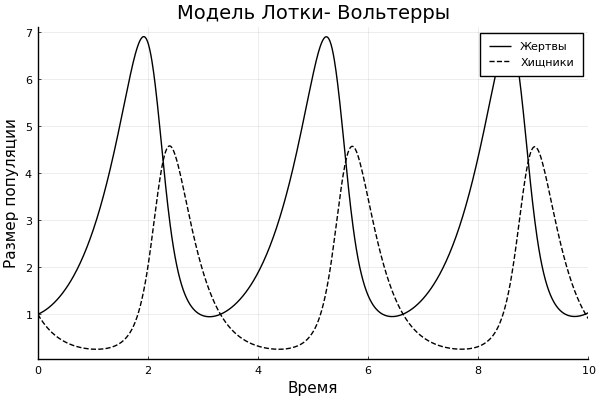

In [31]:
plot(sol, label = ["Жертвы" "Хищники"], color="black", ls=[:solid :dash], title="Модель Лотки- Вольтерры", 
    xaxis="Время",yaxis="Размер популяции")

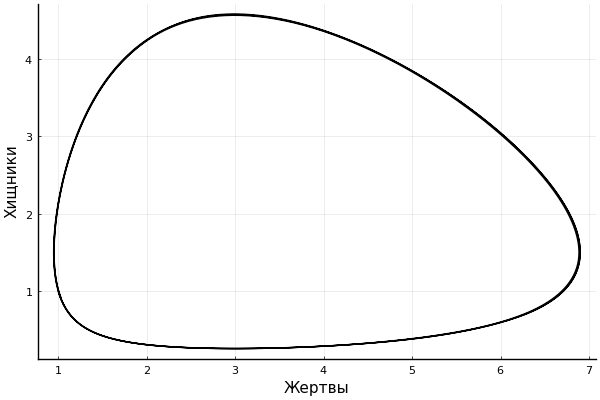

In [32]:
plot(sol,vars=(1,2), color="black", xaxis="Жертвы", yaxis="Хищники", legend=false)

## Задания для самостоятельного выполнения

### Модель Мальтуса

In [235]:
# задаём описание модели:
function lorenz!(du,u,p,t)
    b, c = p
    du[1] = (b-c)*u[1]

end
# задаём начальное условие:
u0 = [146150789]

# задаём знанчения параметров:
p = (2.5, 2.7)

# задаём интервал времени:
tspan = (0.0, 100.0)

# решение:
prob = ODEProblem(lorenz!, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 33-element Vector{Float64}:
   0.0
   0.13797296614631024
   0.9633680539606021
   2.365187743977535
   3.9989569299631347
   6.017945962851735
   8.299536578074452
  10.874489879371303
  13.674528574327585
  16.686540430053498
  19.867647860571488
  23.195537295617157
  26.64163223552912
   ⋮
  60.42552491997608
  64.3203175158615
  68.2259482592793
  72.14019949109965
  76.06130749820188
  79.98786661525509
  83.91876222676552
  87.85311281213939
  91.790231168599
  95.72959936041022
  99.67086868580165
 100.0
u: 33-element Vector{Vector{Float64}}:
 [1.46150789e8]
 [1.4217295321846306e8]
 [1.2053802714506093e8]
 [9.10675378577686e7]
 [6.5683499612690166e7]
 [4.386210415243015e7]
 [2.7791617055435818e7]
 [1.660573501978518e7]
 [9.48534829788749e6]
 [5.193248572091851e6]
 [2.748782305503759e6]
 [1.412848759536041e6]
 [709230.4218854535]
 ⋮
 [825.3287059662334]
 [378.7638072663608]
 [173.44805062959804]
 [79.29070280237548]
 [36.19762

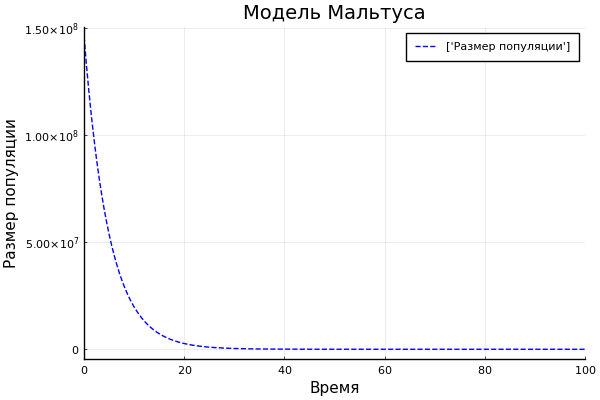

In [63]:
plot(sol, label = ["Размер популяции"], color="blue", ls=:dash, title="Модель Мальтуса",  
    xaxis="Время", yaxis="Размер популяции")

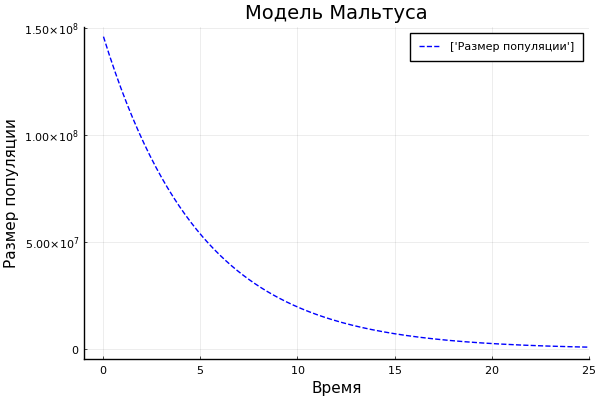

In [81]:
plot(sol, label = ["Размер популяции"], color="blue", ls=:dash, title="Модель Мальтуса",  
    xaxis="Время", yaxis="Размер популяции", xlims=(-1, 25))

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\maltus.gif


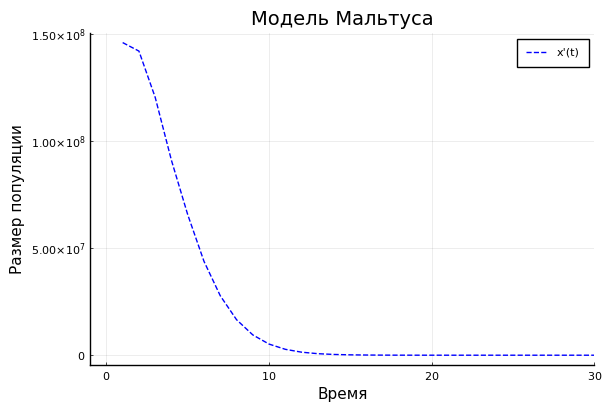

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\maltus.gif")
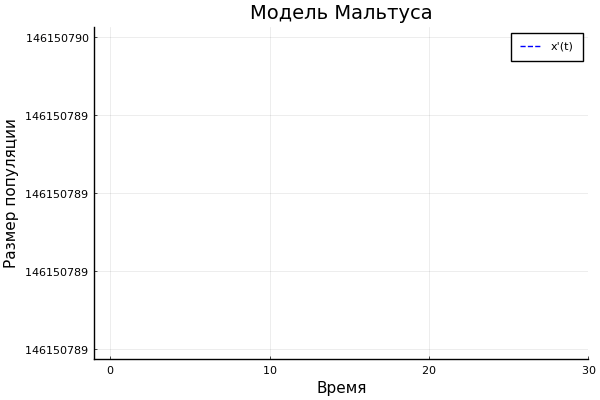

In [84]:
anim = @animate for t in 0.0:0.5:100.0
    plot(sol[sol.t .<= t], 
        label = "x'(t)", color="blue", ls=:dash, title="Модель Мальтуса",  
        xaxis="Время", yaxis="Размер популяции", xlims=(-1, 30))
end
gif(anim, "maltus.gif")

## Логистическая модель роста популяции

In [237]:
# задаём описание модели:
function logistic_population!(du,u,p,t)
    r, k = p
    du[1] = r*u[1] * (1 - u[1]/k)

end
# задаём начальное условие:
u0 = [1000]

# задаём знанчения параметров:
p = (1.7, 1000000)

# задаём интервал времени:
tspan = (0.0, 10.0)

# решение:
prob = ODEProblem(logistic_population!, u0, tspan, p)
sol = solve(prob)

retcode: Success
Interpolation: 3rd order Hermite
t: 20-element Vector{Float64}:
  0.0
  0.08092490211072892
  0.24273377752547187
  0.44728385682754906
  0.6986908888827799
  0.9947091699540147
  1.334543162855148
  1.7154191500254026
  2.135165102478015
  2.592051114188237
  3.0864681058897325
  3.622304155764195
  4.215969483897827
  5.051913541318896
  5.706051453567081
  6.4375373208696764
  7.170224237385194
  8.051592067940058
  9.051111975931533
 10.0
u: 20-element Vector{Vector{Float64}}:
 [1000.0]
 [1147.315493276144]
 [1510.040899224418]
 [2136.660450458517]
 [3272.3131644625428]
 [5401.029883878869]
 [9583.96608466859]
 [18153.93480007776]
 [36369.295528614566]
 [75838.53109417747]
 [159793.22980428167]
 [321075.647967616]
 [564736.4305540917]
 [843144.3551570362]
 [942330.2227290028]
 [982619.8515589942]
 [994920.4891133443]
 [998843.0816280522]
 [999779.2293361427]
 [999954.7965537956]

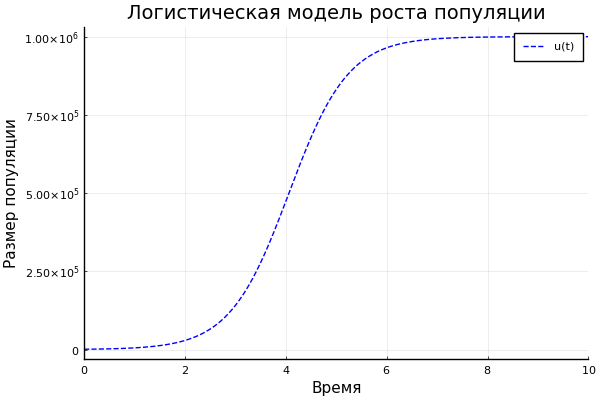

In [94]:
plot(sol, label = "u(t)", color="blue", ls=:dash, title="Логистическая модель роста популяции",  
    xaxis="Время", yaxis="Размер популяции")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\logistic_population.gif


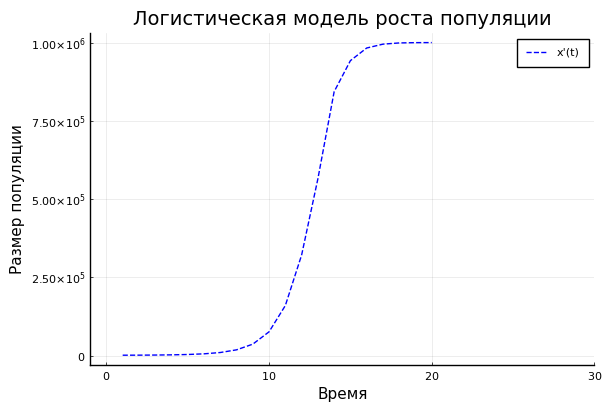

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\logistic_population.gif")
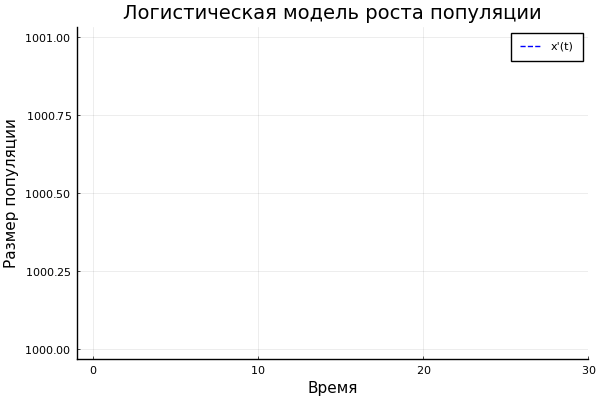

In [238]:
anim = @animate for t in 0.0:1.0:200.0
    plot(sol[sol.t .<= t], 
        label = "x'(t)", color="blue", ls=:dash, title="Логистическая модель роста популяции",  
        xaxis="Время", yaxis="Размер популяции", xlims=(-1, 30))
end
gif(anim, "logistic_population.gif")

## Модель эпидемии SIR

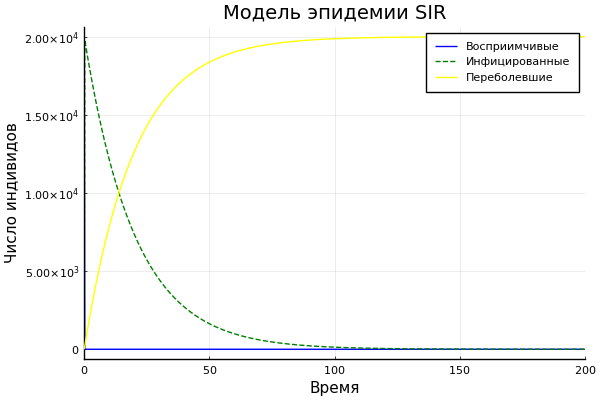

In [240]:
# задаём описание модели:
function sir!(du,u,p,t)
    beta, v = p
    du[1] = -beta * u[2] * u[1]
    du[2] = beta * u[2] * u[1] - v * u[2]
    du[3] = v * u[2]
end

# задаём начальное условие:
u0 = [19896, 99, 5]

# задаём знанчения параметров:
p = (0.1, 0.05) # beta, v

# задаём интервал времени:
tspan = (0.0, 200.0)

# решение:
prob = ODEProblem(sir!, u0, tspan, p)
sol = solve(prob)
plot(sol, color=["blue" "green" "yellow"], ls=[:solid :dash :solid], title="Модель эпидемии SIR", 
    label=["Восприимчивые" "Инфицированные" "Переболевшие"], xaxis="Время", yaxis="Число индивидов")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\sir.gif


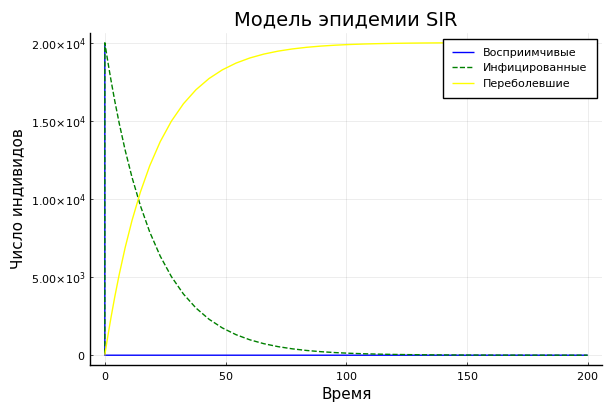

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\sir.gif")
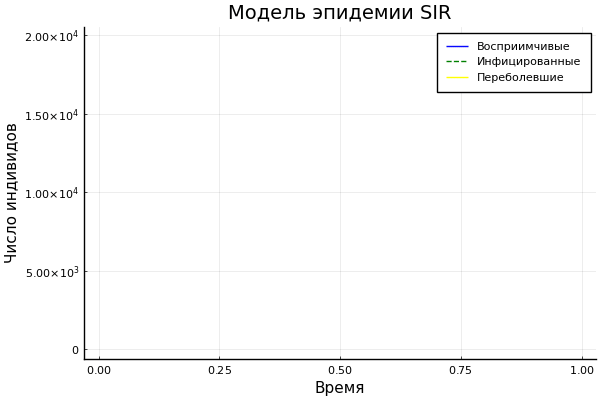

In [241]:
anim = @animate for t in 0.0:1.0:200.0
    plot(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[1, :], color="blue", ls=:solid, title="Модель эпидемии SIR", 
    label="Восприимчивые", xaxis="Время", yaxis="Число индивидов")
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[2, :], color="green", ls=:dash,  label="Инфицированные")
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[3, :], color="yellow", ls=:solid, label="Переболевшие")
end
gif(anim, "sir.gif")

## Расширение модели SIR - SEIR

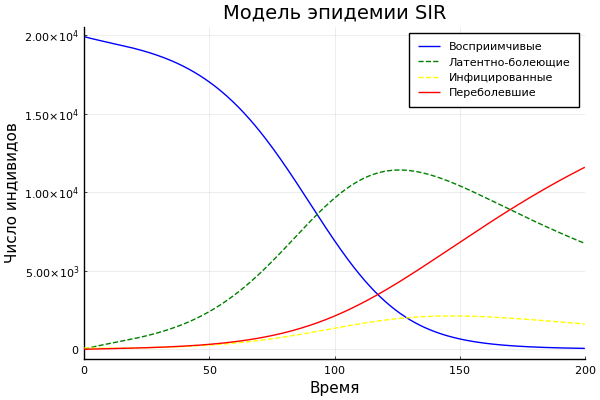

In [169]:
# задаём описание модели:
function seir!(du,u,p,t)
    beta, v, d, N = p
    du[1] = -beta/N * u[1] * u[3]
    du[2] = beta/N * u[1] * u[3] - d * u[2]
    du[3] = d*u[2] - v * u[3]
    du[4] = v * u[3]
end

# задаём начальное условие:
u0 = [19896, 9, 90, 5]

# задаём знанчения параметров:
p = (0.5, 0.05, 0.01, 20000) # beta, v, d, N

# задаём интервал времени:
tspan = (0.0, 200.0)

# решение:
prob = ODEProblem(seir!, u0, tspan, p)
sol = solve(prob)
plot(sol, color=["blue" "green" "yellow" "red"], ls=[:solid :dash :dash :solid], title="Модель эпидемии SIR", 
    label=["Восприимчивые" "Латентно-болеющие" "Инфицированные" "Переболевшие"], xaxis="Время", yaxis="Число индивидов")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\seir.gif


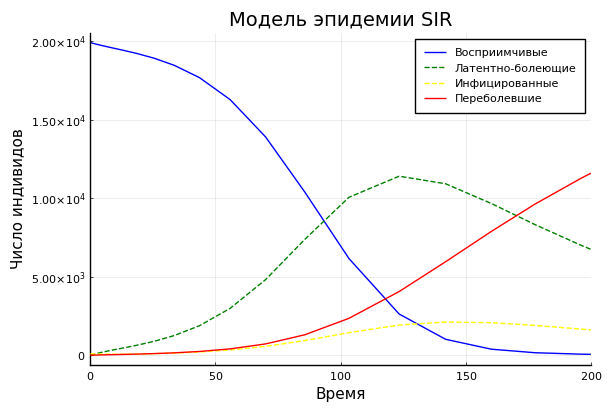

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\seir.gif")
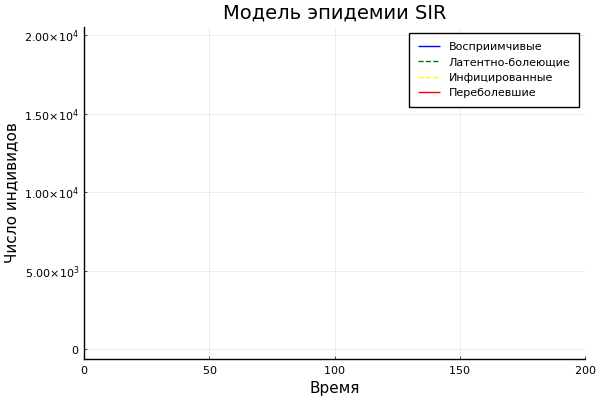

In [171]:
anim = @animate for t in 0.0:1.0:200.0
    plot(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[1, :], color="blue", ls=:solid, title="Модель эпидемии SIR", 
    label="Восприимчивые", xaxis="Время", yaxis="Число индивидов", xlim=(0,200))
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[2, :], color="green", ls=:dash,  label="Латентно-болеющие")
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[3, :], color="yellow", ls=:dash, label="Инфицированные")
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[4, :], color="red", ls=:solid, label="Переболевшие")
end
gif(anim, "seir.gif", fps = 30)

## Дискретная модель Лотки-Вольтерры

In [202]:
import Pkg
Pkg.add("SimpleDiffEq")
using SimpleDiffEq

┌ Warning: attempting to remove probably stale pidfile
│   path = "C:\\Users\\Home\\.julia\\logs\\manifest_usage.toml.pid"
└ @ FileWatching.Pidfile C:\Users\Home\AppData\Local\Programs\Julia-1.11.3\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:278
   Resolving package versions...
┌ Warning: failed to remove pidfile on close
│   path = "C:\\Users\\Home\\.julia\\logs\\manifest_usage.toml.pid"
│   removed = false
└ @ FileWatching.Pidfile C:\Users\Home\AppData\Local\Programs\Julia-1.11.3\share\julia\stdlib\v1.11\FileWatching\src\pidfile.jl:347
error in running finalizer: ErrorException("task switch not allowed from inside gc finalizer")
ijl_error at C:/workdir/src\rtutils.c:41
ijl_switch at C:/workdir/src\task.c:635
try_yieldto at .\task.jl:948
wait at .\task.jl:1022
uv_write at .\stream.jl:1081
unsafe_write at .\stream.jl:1154
unsafe_write at .\io.jl:452 [inlined]
unsafe_write at .\io.jl:803 [inlined]
write at .\io.jl:837
unknown function (ip: 000002499df8ed90)
#handle_message#5 at

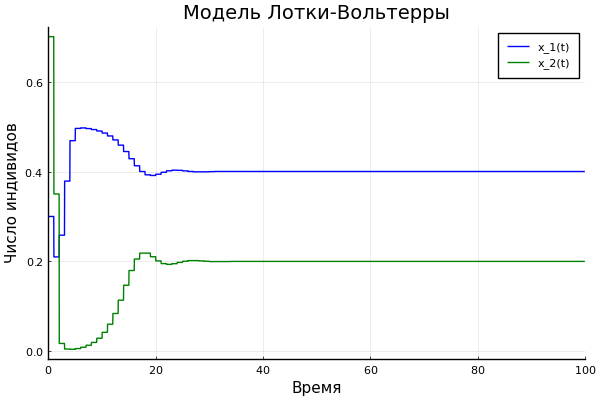

In [234]:
# задаём описание модели:
function lotki_volterr!(du,u,p,t)
    a, c, d = p
    du[1] = a*u[1]*(1-u[1]) - u[1]*u[2]
    du[2] = -c*u[2] +d*u[1]*u[2]
end

# задаём начальное условие:
u0 = [0.3, 0.7]

# задаём знанчения параметров:
p = (2.0, 1.0, 5.0) # a, c, d

# задаём интервал времени:
tspan = (0.0, 100.0)

# решение:
prob = DiscreteProblem(lotki_volterr!, u0, tspan, p)
sol = solve(prob)
plot(sol, color=["blue" "green"], ls=[:solid :solid], title="Модель Лотки-Вольтерры", 
    label=["x_1(t)" "x_2(t)"], xaxis="Время", yaxis="Число индивидов")

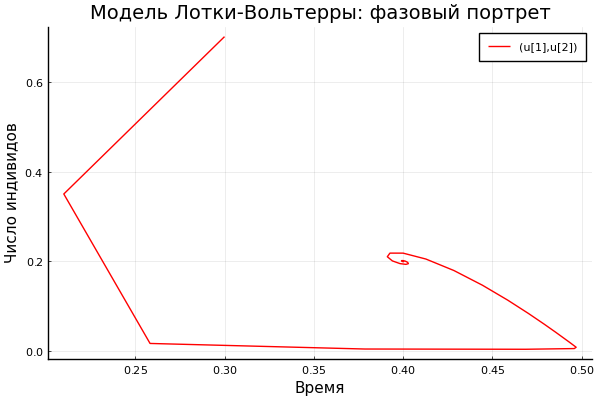

In [205]:
plot(sol, vars=(1,2), color="red", title="Модель Лотки-Вольтерры: фазовый портрет", xaxis="Время", yaxis="Число индивидов")

## Модель конкурентных отношений

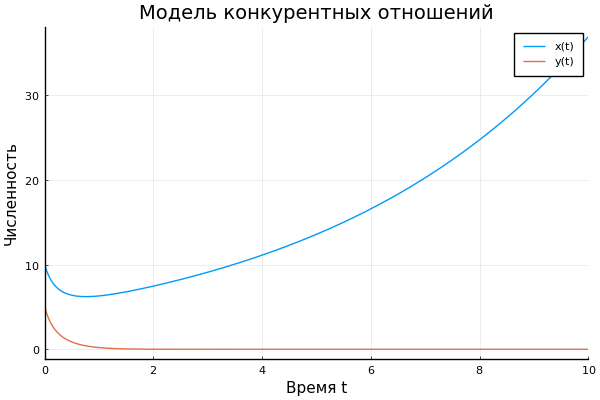

In [216]:
function competition!(du, u, p, t)
    a, b = p
    x, y = u
    du[1] = a * x - b * x * y
    du[2] = a * y - b * x * y
end

a = 0.2
b = 0.5
p = [a, b]
u0 = [10.0, 5.0]
tspan = (0.0, 10.0)
prob = ODEProblem(competition!, u0, tspan, p)
sol = solve(prob)

# График
plot(sol, label=["x(t)" "y(t)"], xlabel="Время t", ylabel="Численность", title="Модель конкурентных отношений")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\competition.gif


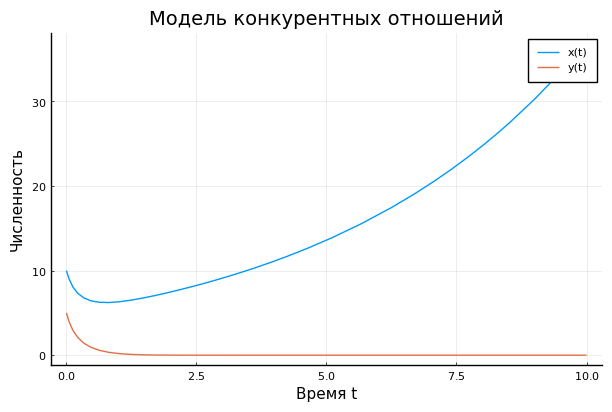

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\competition.gif")
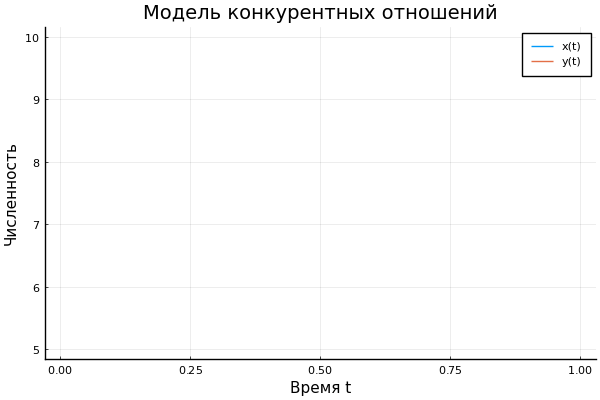

In [221]:
anim = @animate for t in 0.0:1.0:200.0
    plot(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[1, :], label="x(t)", 
        xlabel="Время t", ylabel="Численность", title="Модель конкурентных отношений")
    plot!(sol.t[sol.t .<= t], reduce(hcat, sol.u[sol.t .<= t])[2, :], label="y(t)")
end
gif(anim, "competition.gif")

## Модель консервативного гармонического осциллятора

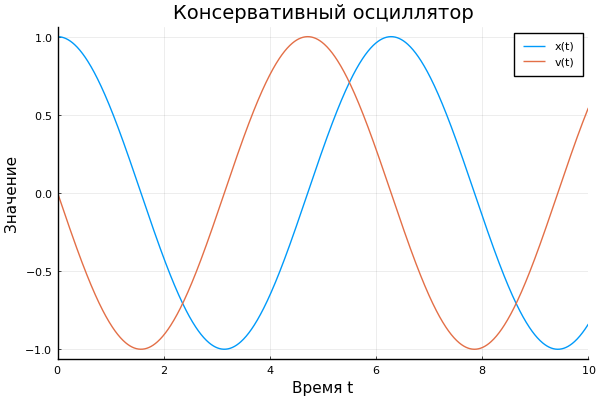

In [222]:
function oscillator_conservative!(du, u, p, t)
    w0 = p[1]
    x, v = u
    du[1] = v
    du[2] = -w0^2 * x
end


p = [1.0]
u0 = [1.0, 0.0]
tspan = (0.0, 10.0)
prob = ODEProblem(oscillator_conservative!, u0, tspan, p)
sol = solve(prob)

plot(sol, label=["x(t)" "v(t)"], xlabel="Время t", ylabel="Значение", title="Консервативный осциллятор")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\oscillator_conservative_animation.gif


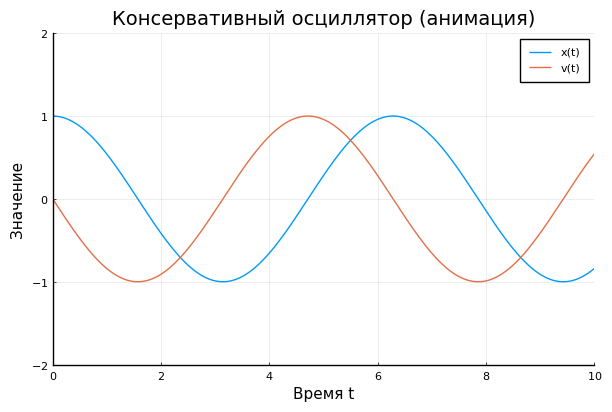

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\oscillator_conservative_animation.gif")
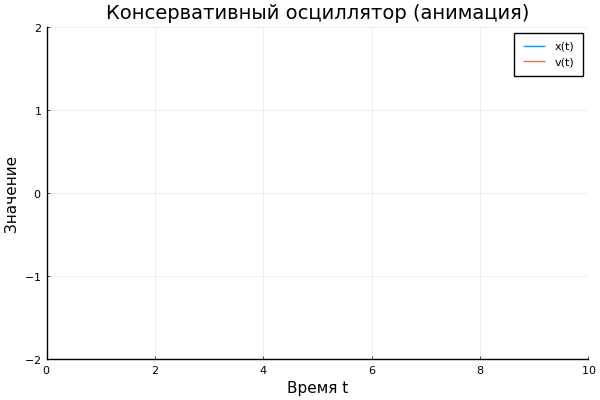

In [223]:
# Анимация
anim = @animate for t in 0:0.1:10
    plot(sol, tspan=(0, t), label=["x(t)" "v(t)"], xlabel="Время t", ylabel="Значение", 
        title="Консервативный осциллятор (анимация)", xlim=(0,10), ylim=(-2,2))
end
gif(anim, "oscillator_conservative_animation.gif", fps=10)

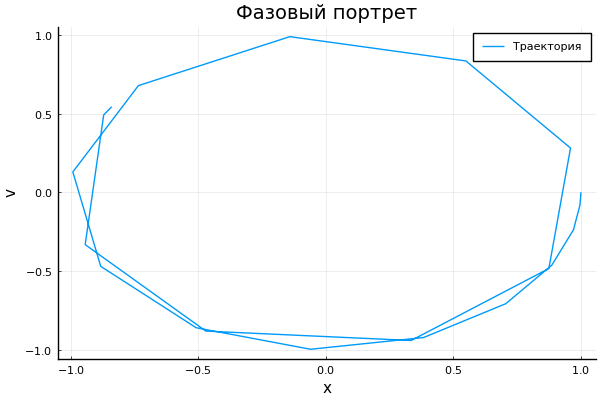

In [224]:
plot(sol[1,:], sol[2,:], label="Траектория", xlabel="x", ylabel="v", title="Фазовый портрет")

## Свободные колебания гармонического осциллятора

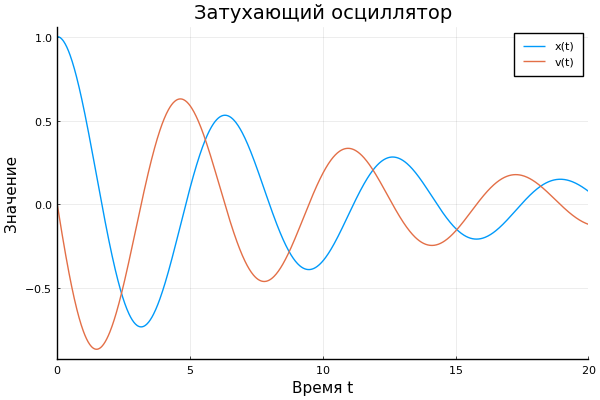

In [226]:
function oscillator_damped!(du, u, p, t)
    w0, g = p
    x, v = u
    du[1] = v
    du[2] = -2*g*v - w0^2 * x
end

p = [1.0, 0.1]
u0 = [1.0, 0.0]
tspan = (0.0, 20.0)
prob = ODEProblem(oscillator_damped!, u0, tspan, p)
sol = solve(prob)
plot(sol, label=["x(t)" "v(t)"], xlabel="Время t", ylabel="Значение", title="Затухающий осциллятор")

[ Info: Saved animation to C:\Users\Home\Documents\РУДН\Компьютерный практикум по статистическому анализу\lab6\oscillator_damped_animation.gif


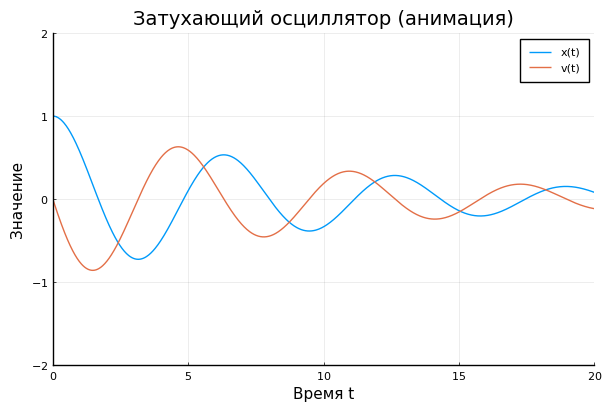

Plots.AnimatedGif("C:\\Users\\Home\\Documents\\РУДН\\Компьютерный практикум по статистическому анализу\\lab6\\oscillator_damped_animation.gif")
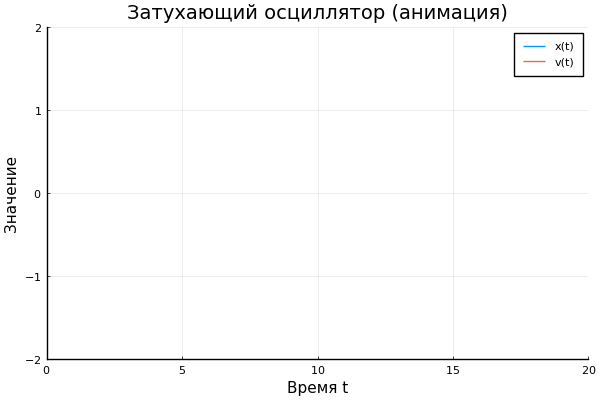

In [230]:
anim = @animate for t in 0:0.2:20
    plot(sol, tspan=(0, t), label=["x(t)" "v(t)"], xlabel="Время t", ylabel="Значение", 
        title="Затухающий осциллятор (анимация)", xlim=(0,20), ylim=(-2,2))
end
gif(anim, "oscillator_damped_animation.gif", fps=10)

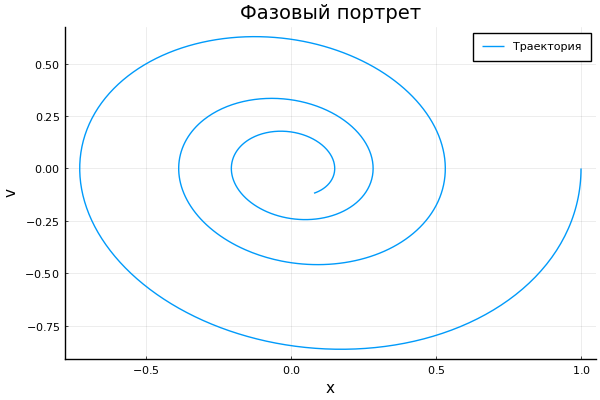

In [229]:
plot(sol, vars=(1,2), label="Траектория", xlabel="x", ylabel="v", title="Фазовый портрет")